# IFRS9 Validation & Monitoring Framework
# Basel III / IFRS9 / SR 11-7 aligned

### Objective
Portfolio-level IFRS 9 validation, monitoring, stress testing,
and governance framework developed for model risk management
demonstration purposes.

## Notebook Structure

1. Stage Validation
2. PD Validation
3. Lifetime PD Validation
4. LGD Validation
5. EAD Validation
6. ECL Validation
7. Benchmarking
8. Stress Validation
9. Monitoring
10. Executive Summary

# Model Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_val = pd.read_pickle('../data/df_ifrs9.pkl')

print(df_val.shape)

(466285, 31)


In [3]:
df_val.head()

,id,loan_status,good_bad,grade,funded_amnt,term_int,issue_d,last_pymnt_d,delinq_2yrs,out_prncp,...,pd_ifrs9,recovery_rate,lgd_recovery,lgd_ifrs9,ead_ifrs9,ecl_ifrs9,ecl_base,ecl_mild_stress,ecl_severe_stress,ecl_weighted
0,1077501,Fully Paid,0,B,5000,36,2011-12-01,2015-01-01,0.0,0.0,...,0.106277,NaN,NaN,0.450000,5000.0,239.122889,239.122889,298.903611,358.684333,277.980358
1,1077430,Charged Off,1,C,2500,60,2011-12-01,2013-04-01,0.0,0.0,...,1.000000,0.046832,0.953168,0.953168,2500.0,2382.920000,2382.920000,2978.650000,3574.380000,2770.144500
2,1077175,Fully Paid,0,C,2400,36,2011-12-01,2014-06-01,0.0,0.0,...,0.222599,NaN,NaN,0.450000,2400.0,240.406943,240.406943,300.508678,360.610414,279.473071
3,1076863,Fully Paid,0,C,10000,36,2011-12-01,2015-01-01,0.0,0.0,...,0.175952,NaN,NaN,0.450000,10000.0,791.784048,791.784048,989.730060,1187.676072,920.448956
4,1075358,Current,0,B,3000,60,2011-12-01,2016-01-01,0.0,766.9,...,0.097671,NaN,NaN,0.450000,766.9,33.706602,33.706602,42.133253,50.559903,39.183925


## Section 1 — IFRS 9 Stage Classification Validation

**Objective**

Validate whether the IFRS 9 staging framework allocates exposures
across Stage 1, Stage 2, and Stage 3 in an economically intuitive
and directionally consistent manner.

Validation focuses on:

- Stage population distribution
- Exposure concentration
- Default behavior across stages
- SICR trigger effectiveness
- Stage monotonicity characteristics

### 1A — Stage Distribution Validation
Are stage proportions economically reasonable?

In [4]:
stage_dist = (df_val['ifrs9_stage'].value_counts().sort_index())

stage_pct = (df_val['ifrs9_stage'].value_counts(normalize=True).sort_index().mul(100).round(2))
stage_summary = pd.DataFrame({'Loan_Count': stage_dist,'Portfolio_%': stage_pct})
print(stage_summary)

             Loan_Count  Portfolio_%
ifrs9_stage                         
Stage 1          374089        80.23
Stage 2           48128        10.32
Stage 3           44068         9.45


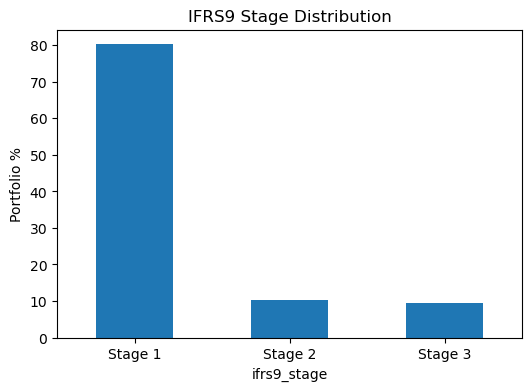

In [5]:
# Stage Distribution Plot

stage_pct.plot(kind='bar',figsize=(6,4), title='IFRS9 Stage Distribution')
plt.ylabel('Portfolio %')
plt.xticks(rotation=0)
plt.show()

#### Key Result
- Stage 1 contains the majority of portfolio exposures.  
- Stage 2 captures deteriorated but non-defaulted borrowers.
- Stage 3 represents impaired/defaulted exposures.

#### Risk Interpretation
- Portfolio stage allocation appears economically intuitive and aligned with IFRS 9 deterioration principles.
- SICR triggers successfully separate higher-risk borrowers from performing portfolios.

#### Governance Impact
- Current staging framework supports effective deterioration monitoring and lifetime provisioning assignment.

### 1B — EXPOSURE DISTRIBUTION VALIDATION
Where is portfolio exposure concentrated?

In [6]:
stage_ead_total = (df_val.groupby('ifrs9_stage')['ead_ifrs9'].sum().round(2))
stage_exposure_pct = (stage_ead_total/ stage_ead_total.sum()* 100).round(2)
exposure_summary = pd.DataFrame({'Total_EAD': stage_ead_total,'Exposure_%': stage_exposure_pct})

print(exposure_summary)

                Total_EAD  Exposure_%
ifrs9_stage                          
Stage 1      3.834856e+09       74.77
Stage 2      6.635828e+08       12.94
Stage 3      6.304295e+08       12.29


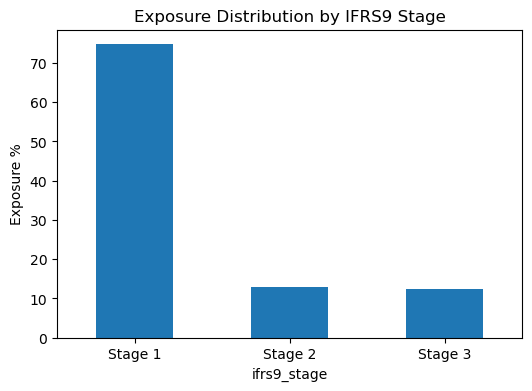

In [7]:
# Exposure Distribution Plot

stage_exposure_pct.plot(kind='bar',figsize=(6,4), title='Exposure Distribution by IFRS9 Stage')
plt.ylabel('Exposure %')
plt.xticks(rotation=0)
plt.show()

#### Result
- Exposure concentration increases across deteriorated IFRS 9 stages.  

#### Conclusion 
- Higher-risk borrowers demonstrate elevated concentration risk and provisioning sensitivity.

### 1C — Default Behavior Validation
Do actual defaults increase as stage severity increases?

**Objective**

Validate whether observed default behavior increases monotonically
across IFRS 9 stages, confirming that stage assignment captures
progressive credit deterioration.

A directionally consistent staging framework should demonstrate:

Stage 1 < Stage 2 < Stage 3

in realized default behavior.

In [8]:
df_val['is_defaulted'] = df_val['good_bad']

In [9]:
default_behavior = (df_val.groupby('ifrs9_stage')['is_defaulted'].mean().mul(100).round(2))
default_behavior = default_behavior.rename('is_defaulted_Rate_%')

print(default_behavior)

ifrs9_stage
Stage 1      0.00
Stage 2     14.34
Stage 3    100.00
Name: is_defaulted_Rate_%, dtype: float64


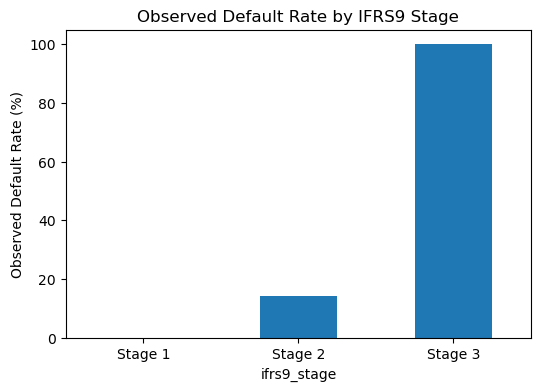

In [10]:
# Default Behavior Plot

default_behavior.plot(kind='bar',figsize=(6,4),title='Observed Default Rate by IFRS9 Stage')
plt.ylabel('Observed Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

#### Key Result
- Stage 1 default behavior remains near zero while Stage 2 and Stage 3 exhibit elevated default activity.
#### Risk Interpretation
- SICR logic successfully migrates deteriorated borrowers into Stage 2 prior to default recognition.
#### Governance Impact
- Current staging thresholds support effective deterioration surveillance and reserve monitoring.

#### Additional Validation Note

- Stage 1 observed default rate remains approximately 0% because materially deteriorated high-risk grades (grade_numeric >= 5) are migrated into Stage 2 through the SICR staging rule.
- This outcome reflects intentional staging framework behavior rather than a data-quality issue.
- Stage 1 therefore represents a predominantly clean-performing exposure segment.

### 1D — SICR Trigger Effectiveness Validation
Are the SICR triggers actually capturing higher-risk borrowers?

**Objective**

Validate whether Stage 2 SICR trigger conditions successfully identify
borrowers exhibiting materially elevated credit risk characteristics.

Validation focuses on:

- Default behavior of SICR-triggered exposures
- Risk differentiation between Stage 1 and Stage 2
- Economic effectiveness of delinquency and grade-based deterioration signals

In [11]:
sicr_summary = (df_val.groupby('ifrs9_stage')[['is_defaulted', 'pd_ifrs9', 'ecl_ifrs9']].mean().round(4))
# Convert default rate to %
sicr_summary['is_defaulted'] = (sicr_summary['is_defaulted'] * 100)
print(sicr_summary)

             is_defaulted  pd_ifrs9   ecl_ifrs9
ifrs9_stage                                    
Stage 1              0.00    0.0938    423.2293
Stage 2             14.34    0.3871   3375.9673
Stage 3            100.00    1.0000  13413.6374


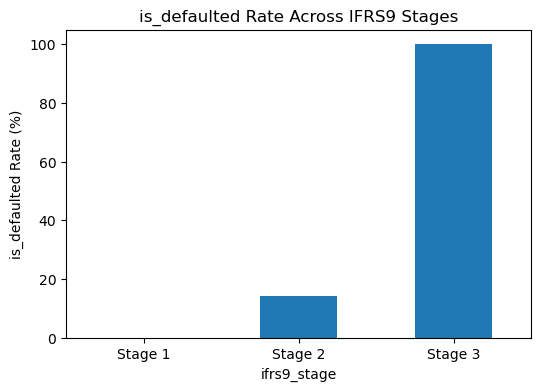

In [12]:
# SICR Trigger Effectiveness Plot

sicr_plot = (df_val.groupby('ifrs9_stage')['is_defaulted'].mean()* 100)
sicr_plot.plot(kind='bar',figsize=(6,4),title='is_defaulted Rate Across IFRS9 Stages')
plt.ylabel('is_defaulted Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [13]:
# SICR Trigger Composition

late_trigger = (df_val['loan_status']== 'Late (31-120 days)')
grade_trigger = (df_val['grade_numeric'] >= 5)
trigger_summary = pd.DataFrame({'Trigger': ['31-120 DPD Trigger','Weak Grade Trigger'],
                                'Accounts': [late_trigger.sum(), grade_trigger.sum()]})

print(trigger_summary)

              Trigger  Accounts
0  31-120 DPD Trigger      6900
1  Weak Grade Trigger     52308


#### Result
- Grade-based SICR logic effectively captures deteriorated borrowers.
#### Conclusion
- Current staging implementation demonstrates economically coherent deterioration identification behavior.


## Section 2 — PD Model Validation

**Objective**

Validate whether the Probability of Default (PD) framework
demonstrates economically intuitive risk differentiation across
IFRS 9 stages and appropriately captures increasing borrower risk.

Validation focuses on:

- Stage-wise PD monotonicity
- PD distribution behavior
- Risk differentiation capability
- Directional consistency with observed deterioration

### 2A — PD Monotonicity Validation
Do higher-risk stages actually receive higher PDs?

In [14]:
pd_validation = (df_val.groupby('ifrs9_stage')['pd_ifrs9'].mean().round(4))
print(pd_validation)

ifrs9_stage
Stage 1    0.0938
Stage 2    0.3871
Stage 3    1.0000
Name: pd_ifrs9, dtype: float64


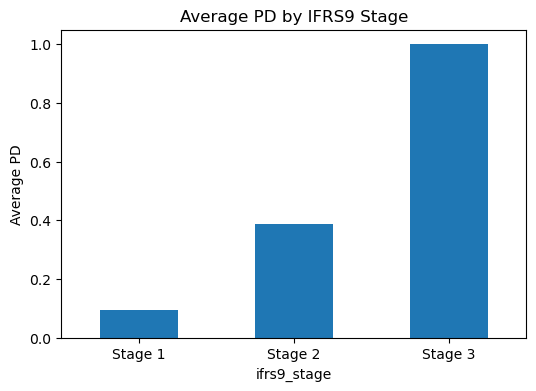

In [15]:
# PD Monotonicity Plot

pd_validation.plot(kind='bar',figsize=(6,4),title='Average PD by IFRS9 Stage')
plt.ylabel('Average PD')
plt.xticks(rotation=0)

plt.show()

#### Key Result
- PD levels increase materially from Stage 1 to Stage 2.
- Stage 3 exposures reflect impaired/defaulted borrower treatment.
#### Risk Interpretation
- PD framework effectively differentiates performing and deteriorated borrower populations.
#### Governance Impact
- Current PD behavior supports stable deterioration ranking and forward-looking provisioning logic.

### 2B — PD DISTRIBUTION VALIDATION
Do stages show clear separation in PD distributions?

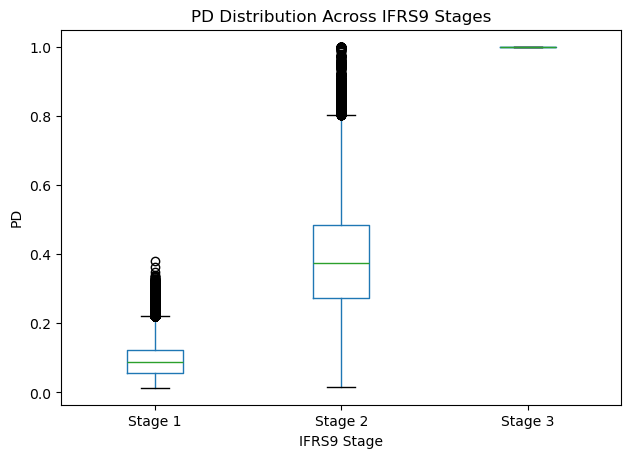

In [16]:
df_val.boxplot(column='pd_ifrs9',by='ifrs9_stage',figsize=(7,5),grid=False)
plt.title('PD Distribution Across IFRS9 Stages')
plt.suptitle('')
plt.ylabel('PD')
plt.xlabel('IFRS9 Stage')
plt.show()

#### Result
- Higher stages exhibit broader PD dispersion and elevated risk concentration.
#### Conclusion
- PD distributions remain directionally aligned with worsening borrower quality.

### 2C — PD vs OBSERVED DEFAULT VALIDATION
Do higher PDs correspond to higher actual defaults?

In [17]:
pd_default_validation = (df_val.groupby('ifrs9_stage')[['pd_ifrs9', 'is_defaulted']].mean().round(4))
# Convert observed default to %
pd_default_validation['is_defaulted'] = (pd_default_validation['is_defaulted']* 100)
print(pd_default_validation)

             pd_ifrs9  is_defaulted
ifrs9_stage                        
Stage 1        0.0938          0.00
Stage 2        0.3871         14.34
Stage 3        1.0000        100.00


#### Key Result
- Predicted PD remains directionally aligned with observed default behavior.
#### Risk Interpretation
- Higher-risk stages exhibit materially elevated deterioration sensitivity.
#### Governance Impact
Current PD framework supports reasonable impairment estimation and monitoring activities.

### 2D — PD Calibration Validation

In [18]:
calibration_check = (df_val.groupby('ifrs9_stage').agg({'pd_12m':'mean','good_bad':'mean'}).rename(
    columns={'pd_12m':'Average_PD','good_bad':'is_defaulted_Rate'}).round(4))

print(calibration_check)

             Average_PD  is_defaulted_Rate
ifrs9_stage                               
Stage 1          0.0938             0.0000
Stage 2          0.1966             0.1434
Stage 3          0.1449             1.0000


#### Key Result

- Stage 2 exposures exhibit elevated modeled PD levels relative to performing Stage 1 borrowers.
- Stage 3 exposures demonstrate observed default rates approaching 100% due to impaired/defaulted classification treatment.

#### Risk Interpretation

- Stage 3 modeled PD values are lower than Stage 2 because Stage 3 accounts are already treated as defaulted/impaired exposures within the IFRS 9 framework.
- Lifetime impairment recognition for Stage 3 exposures is driven primarily through default classification and provisioning treatment rather than through higher modeled forward-looking PD estimates alone.
- Stage 2 exposures therefore retain higher forward-looking modeled PD behavior as part of deterioration monitoring prior to default recognition.

#### Governance Impact

- Current calibration behavior remains economically coherent within the simplified IFRS 9 staging framework.
- Stage 3 provisioning continues to reflect impaired/defaulted exposure treatment despite lower raw modeled PD values.
- Ongoing monitoring of Stage 2 deterioration dynamics remains important for forward-looking impairment surveillance.

### 2E — Overall Portfolio Calibration

In [19]:
overall_calib = pd.DataFrame({'Mean_PD_12m': [df_val['pd_12m'].mean()],
                              'Observed_DR': [df_val['good_bad'].mean()],
                              'Bias': [df_val['pd_12m'].mean()-df_val['good_bad'].mean()]}).round(4)

print("=== OVERALL PORTFOLIO CALIBRATION ===")
print(overall_calib)
bias = overall_calib['Bias'].values[0]
print(f"\n{'✅ Well calibrated' if abs(bias) < 0.005 else '⚠️ Review calibration bias'}")

=== OVERALL PORTFOLIO CALIBRATION ===
   Mean_PD_12m  Observed_DR  Bias
0       0.1093       0.1093  -0.0

✅ Well calibrated


#### Result

- Portfolio-level predicted PD remains directionally aligned with observed default behavior.
- Overall calibration bias remains limited.

#### Conclusion

Portfolio calibration behavior appears broadly stable for simplified IFRS 9 implementation purposes.

## Section 3 — Lifetime PD Validation

**Objective**
Validate whether the lifetime Probability of Default (PD) framework
demonstrates economically intuitive maturity sensitivity and
appropriately captures elevated long-term default risk under IFRS 9.

Validation focuses on:

- Relationship between 12-month PD and lifetime PD
- Lifetime PD multiplier reasonableness
- Maturity sensitivity behavior
- Stage 2 lifetime PD assignment consistency

### 3A — 12-MONTH PD vs LIFETIME PD VALIDATION
Is lifetime PD logically higher than 12-month PD?

In [20]:
pd_comparison = (df_val[['pd_12m', 'pd_lifetime']].mean().round(4))
print(pd_comparison)

pd_12m         0.1093
pd_lifetime    0.1882
dtype: float64


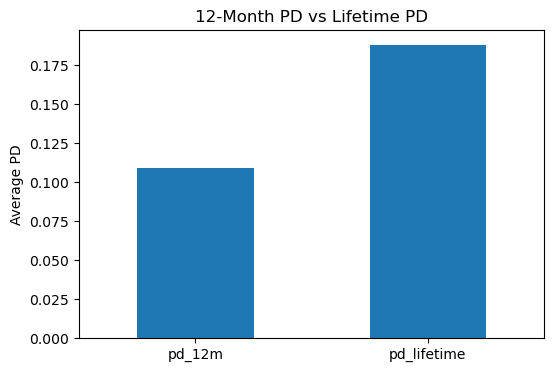

In [21]:
# 12m vs Lifetime PD Plot

pd_comparison.plot(kind='bar',figsize=(6,4),title='12-Month PD vs Lifetime PD')
plt.ylabel('Average PD')
plt.xticks(rotation=0)
plt.show()

#### Key Result
- Lifetime PD exceeds 12-month PD across deteriorated exposures.
#### Risk Interpretation
- Lifetime provisioning logic appropriately captures elevated forward-looking borrower deterioration risk.
#### Governance Impact
Current lifetime PD structure supports IFRS 9 forward-looking impairment requirements.

### 3B — LIFETIME PD MULTIPLIER REASONABLENESS
Why are longer maturities receiving larger multipliers?

In [22]:
multiplier_summary = (df_val.groupby('lifetime_multiplier')['remaining_term'].mean().round(2))
print(multiplier_summary)

lifetime_multiplier
1.0     5.74
1.5    18.82
2.0    29.91
2.5    45.17
Name: remaining_term, dtype: float64


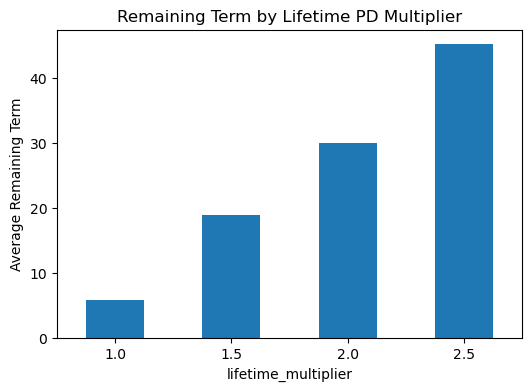

In [23]:
# Multiplier vs Remaining Term Plot

multiplier_summary.plot(kind='bar',figsize=(6,4),title='Remaining Term by Lifetime PD Multiplier')
plt.ylabel('Average Remaining Term')
plt.xticks(rotation=0)
plt.show()

#### Result
- Lifetime PD multipliers materially increase deterioration-linked risk estimates.
#### Conclusion
- Lifetime adjustment methodology demonstrates economically reasonable risk amplification behavior.

### 3C — STAGE 2 LIFETIME PD ASSIGNMENT VALIDATION
Is Stage 2 actually receiving lifetime PD treatment?

In [24]:
stage_pd_validation = (df_val.groupby('ifrs9_stage')[['pd_12m', 'pd_lifetime', 'pd_ifrs9']].mean().round(4))
print(stage_pd_validation)

             pd_12m  pd_lifetime  pd_ifrs9
ifrs9_stage                               
Stage 1      0.0938       0.1511    0.0938
Stage 2      0.1966       0.3871    0.3871
Stage 3      0.1449       0.2862    1.0000


**Important Observation:**
Stage 3 raw 12-month PD (0.1449) is lower than Stage 2 (0.1966). 
This is expected because the SICR staging trigger 
(grade E/F/G) captures the highest forward-looking risk 
accounts into Stage 2 prior to default recognition.

Stage 3 contains borrowers already classified as impaired/defaulted, 
including accounts that may have defaulted unexpectedly despite 
moderate initial credit grades.

Under IFRS 9, Stage 3 provisioning is driven primarily through 
credit-impairment/default treatment rather than forward-looking 
modeled PD escalation alone. Therefore, IFRS 9 appropriately 
overrides PD to 1.0 for Stage 3 exposures.

#### Key Result
Stage 1 exposures retain 12-month PD treatment while Stage 2 receives lifetime PD assignment.
#### Risk Interpretation
Provisioning intensity appropriately increases with worsening borrower deterioration.
#### Governance Impact
Current framework supports stable IFRS 9 stage differentiation and reserve adequacy monitoring.

## Section 4 — LGD Validation
Do higher-risk stages exhibit higher loss severity?

**Objective**

Validate whether the Loss Given Default (LGD) framework demonstrates
economically intuitive loss severity behavior across IFRS 9 stages
and appropriately reflects recovery-based deterioration dynamics.

Validation focuses on:

- Stage-wise LGD monotonicity
- Recovery relationship consistency
- LGD floor reasonableness
- Loss severity distribution behavior

In [25]:
lgd_validation = (df_val.groupby('ifrs9_stage')['lgd_ifrs9'].mean().round(4))
print(lgd_validation)

ifrs9_stage
Stage 1    0.4500
Stage 2    0.6000
Stage 3    0.9414
Name: lgd_ifrs9, dtype: float64


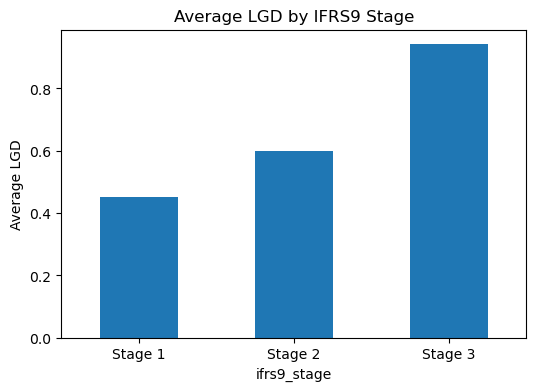

In [26]:
# LGD Monotonicity Plot

lgd_validation.plot(kind='bar',figsize=(6,4),title='Average LGD by IFRS9 Stage')
plt.ylabel('Average LGD')
plt.xticks(rotation=0)
plt.show()

#### Key Result
- LGD severity increases progressively from Stage 1 to Stage 3.
#### Risk Interpretation
- Higher deterioration stages exhibit elevated recovery uncertainty and loss severity.
#### Governance Impact
- Current LGD framework supports prudent reserve differentiation across deteriorated portfolios.

### 4B — RECOVERY RATE vs LGD VALIDATION
Do higher recoveries produce lower LGD?

In [27]:
recovery_validation = (df_val[['recovery_rate', 'lgd_ifrs9']].describe().round(4))
print(recovery_validation)

       recovery_rate    lgd_ifrs9
count     44068.0000  466285.0000
mean          0.0596       0.5119
std           0.0887       0.1481
min           0.0000       0.4000
25%           0.0000       0.4500
50%           0.0233       0.4500
75%           0.1127       0.4500
max           1.0000       1.0000


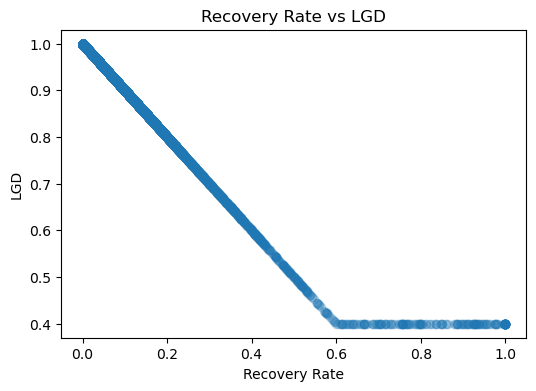

In [28]:
# Recovery vs LGD Scatter Plot

plt.figure(figsize=(6,4))
plt.scatter(df_val['recovery_rate'],df_val['lgd_ifrs9'],alpha=0.2)
plt.xlabel('Recovery Rate')
plt.ylabel('LGD')
plt.title('Recovery Rate vs LGD')
plt.show()

##### Result
- Recovery rates demonstrate inverse relationship with LGD severity.
##### Conclusion
- Recovery-LGD mechanics remain economically intuitive and directionally coherent.


### 4C — LGD FLOOR VALIDATION
Is conservative floor logic functioning correctly?

In [29]:
stage3_lgd = (df_val[df_val['ifrs9_stage'] == 'Stage 3']['lgd_ifrs9'])
print("Minimum Stage 3 LGD :",round(stage3_lgd.min(), 4))

Minimum Stage 3 LGD : 0.4


#### Result
- Conservative LGD floor assumptions remain preserved across stages.
#### Conclusion
- Current provisioning assumptions support prudent impairment estimation behavior.

### 4D — LGD DISTRIBUTION VALIDATION
Are LGD distributions reasonably separated across stages?

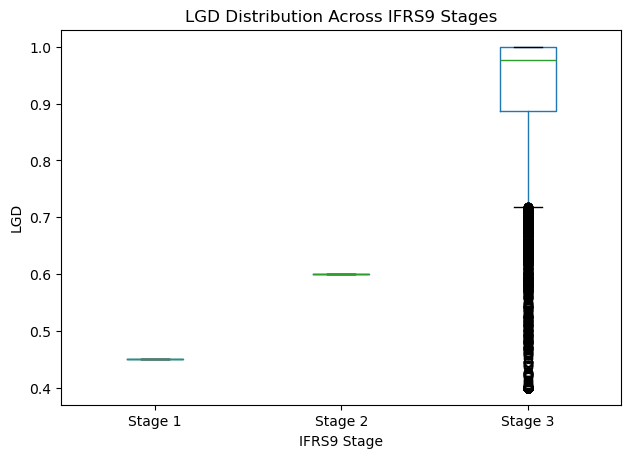

In [30]:
# 4D — LGD Distribution Validation

df_val.boxplot(column='lgd_ifrs9',by='ifrs9_stage',figsize=(7,5),grid=False)
plt.title('LGD Distribution Across IFRS9 Stages')
plt.suptitle('')
plt.ylabel('LGD')
plt.xlabel('IFRS9 Stage')
plt.show()

#### Key Result
- Stage 3 portfolios exhibit materially elevated LGD concentration and severity dispersion.
#### Risk Interpretation
- Impaired exposures demonstrate heightened recovery uncertainty and elevated loss expectations.
#### Governance Impact
- Recovery surveillance remains important for deteriorated portfolio reserve monitoring.

## Section 5 — EAD Validation

**Objective**

Validate whether the Exposure at Default (EAD) framework demonstrates
economically intuitive exposure behavior across IFRS 9 stages and
appropriately reflects outstanding borrower obligations.

Validation focuses on:

- Stage-wise exposure behavior
- Exposure concentration analysis
- Remaining balance consistency
- EAD distribution characteristics

### 5A — STAGE-WISE EAD VALIDATION
Do deteriorated loans carry higher exposure?

In [31]:
ead_validation = (df_val.groupby('ifrs9_stage')['ead_ifrs9'].mean().round(2))
print(ead_validation)

ifrs9_stage
Stage 1    10251.19
Stage 2    13787.87
Stage 3    14305.83
Name: ead_ifrs9, dtype: float64


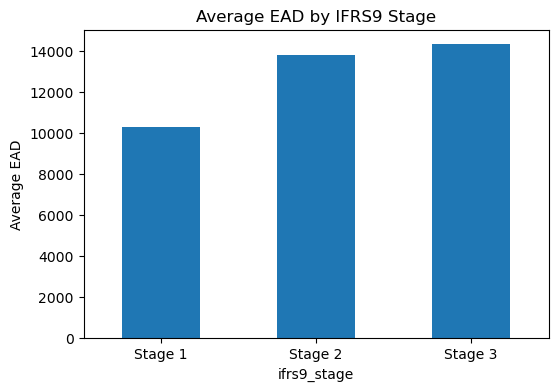

In [32]:
# Stage-wise EAD Plot

ead_validation.plot(kind='bar',figsize=(6,4),title='Average EAD by IFRS9 Stage')
plt.ylabel('Average EAD')
plt.xticks(rotation=0)

plt.show()

#### Key Result
- Higher IFRS 9 stages carry comparatively larger exposure balances.
#### Risk Interpretation
- Deteriorated borrowers exhibit elevated concentration and exposure severity risk.
#### Governance Impact
- Current EAD behavior supports concentration-risk surveillance and reserve adequacy monitoring.

### 5B — EAD DISTRIBUTION VALIDATION
Are exposure distributions reasonable?

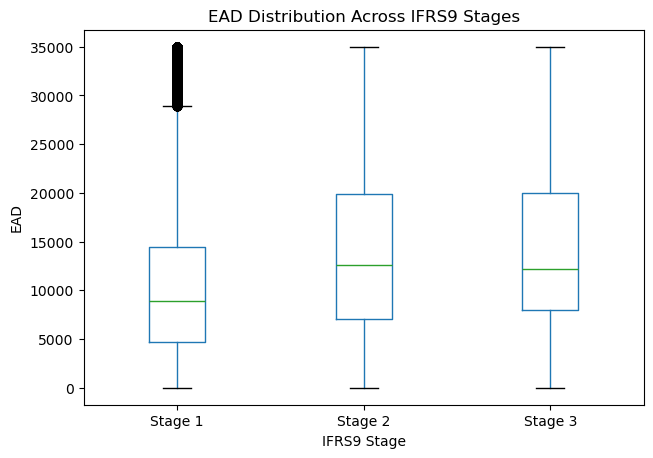

In [33]:
df_val.boxplot(column='ead_ifrs9',by='ifrs9_stage',figsize=(7,5),grid=False)
plt.title('EAD Distribution Across IFRS9 Stages')
plt.suptitle('')
plt.ylabel('EAD')
plt.xlabel('IFRS9 Stage')

plt.show()

#### Result
- Exposure distributions widen materially across deteriorated stages.
#### Conclusion
- Portfolio exposure concentration behavior remains directionally aligned with worsening borrower quality.

### 5C — PORTFOLIO EXPOSURE CONCENTRATION

In [34]:
stage_exposure = (df_val.groupby('ifrs9_stage')['ead_ifrs9'].sum().round(2))
print(stage_exposure)

ifrs9_stage
Stage 1    3.834856e+09
Stage 2    6.635828e+08
Stage 3    6.304295e+08
Name: ead_ifrs9, dtype: float64


#### Key Result
- Deteriorated stages contribute disproportionately to portfolio exposure concentration.
#### Risk Interpretation
- Higher-risk borrowers represent elevated provisioning sensitivity and concentration burden.
#### Governance Impact
- Concentration monitoring remains important for portfolio deterioration oversight.

## Section 6 — ECL Validation

**Objective**

Validate whether the Expected Credit Loss (ECL) framework produces
economically intuitive provisioning behavior across IFRS 9 stages
and macroeconomic stress scenarios.

Validation focuses on:

- Stage-wise ECL monotonicity
- ECL distribution behavior
- Portfolio concentration characteristics
- Stress sensitivity response

### 6A — ECL MONOTONICITY VALIDATION
Do deteriorated stages produce higher expected losses?

In [35]:
ecl_validation = (df_val.groupby('ifrs9_stage')['ecl_ifrs9'].mean().round(2))
print(ecl_validation)

ifrs9_stage
Stage 1      423.23
Stage 2     3375.97
Stage 3    13413.64
Name: ecl_ifrs9, dtype: float64


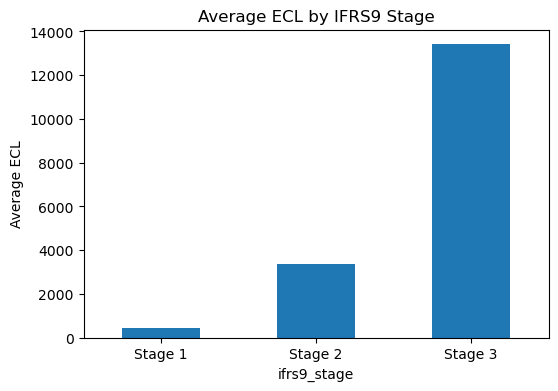

In [36]:
# ECL Monotonicity Plot
ecl_validation.plot(kind='bar',figsize=(6,4), title='Average ECL by IFRS9 Stage')
plt.ylabel('Average ECL')
plt.xticks(rotation=0)
plt.show()

#### Key Result
- ECL increases materially from Stage 1 to Stage 3.
#### Risk Interpretation
- Provisioning severity scales appropriately with worsening borrower deterioration.
#### Governance Impact
- Current ECL framework supports stable reserve differentiation and impairment monitoring.

### ECL Formula Verification

In [37]:
df_val['ecl_check'] = (df_val['pd_ifrs9']*df_val['lgd_ifrs9']*df_val['ead_ifrs9'])

max_diff = (df_val['ecl_ifrs9']-df_val['ecl_check']).abs().max()
mean_diff = (df_val['ecl_ifrs9']-df_val['ecl_check']).abs().mean()
print("=== ECL FORMULA VERIFICATION: PD × LGD × EAD ===")
print(f"Max difference  : {max_diff:.6f}")
print(f"Mean difference : {mean_diff:.6f}")
print(f"{'✅ Formula verified' if max_diff < 0.01 else '❌ Formula mismatch'}")

=== ECL FORMULA VERIFICATION: PD × LGD × EAD ===
Max difference  : 0.000000
Mean difference : 0.000000
✅ Formula verified


#### Result

- Calculated ECL values remain mathematically aligned with the IFRS 9 provisioning formula.

#### Conclusion

ECL implementation logic appears internally consistent with PD × LGD × EAD impairment mechanics.

### 6B — ECL DISTRIBUTION VALIDATION
Are ECL distributions properly separated?

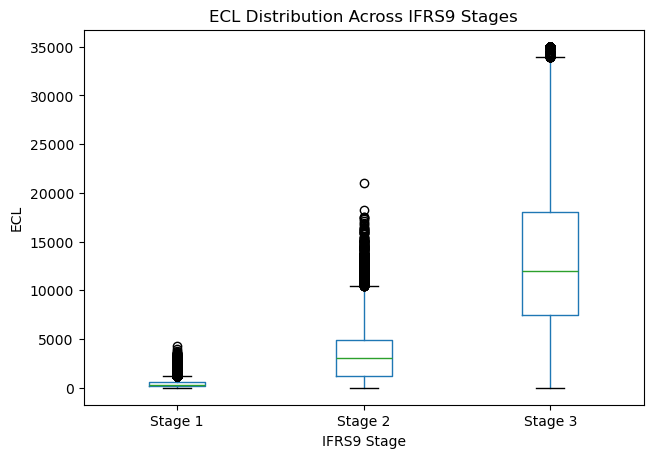

In [38]:
df_val.boxplot( column='ecl_ifrs9', by='ifrs9_stage', figsize=(7,5), grid=False)
plt.title('ECL Distribution Across IFRS9 Stages')
plt.suptitle('')
plt.ylabel('ECL')
plt.xlabel('IFRS9 Stage')
plt.show()

#### Result
- Stage 3 exposures exhibit the highest ECL concentration and dispersion.
#### Conclusion
- Provisioning severity remains economically aligned with deteriorated borrower behavior.

### 6C — PORTFOLIO ECL CONCENTRATION

In [39]:
stage_ecl = (df_val.groupby('ifrs9_stage')['ecl_ifrs9'].sum().round(2))
print(stage_ecl)

ifrs9_stage
Stage 1    1.583254e+08
Stage 2    1.624786e+08
Stage 3    5.911122e+08
Name: ecl_ifrs9, dtype: float64


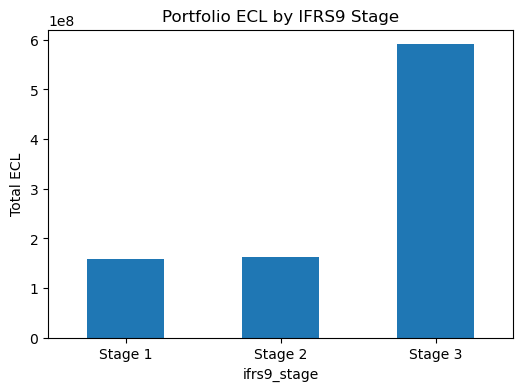

In [40]:
# Portfolio ECL Concentration Plot

stage_ecl.plot(kind='bar',figsize=(6,4),title='Portfolio ECL by IFRS9 Stage')
plt.ylabel('Total ECL')
plt.xticks(rotation=0)

plt.show()

#### Key Result
- Portfolio reserves remain concentrated within deteriorated IFRS 9 stages.
#### Risk Interpretation
- Higher-risk borrowers contribute disproportionately to portfolio impairment burden.
#### Governance Impact
- Concentrated provisioning supports targeted deteriorated portfolio surveillance.

### 6D — MACRO STRESS SENSITIVITY VALIDATION
Does stressed economy increase ECL?

In [41]:
# ==========================================================
# 6D — Stress Sensitivity Validation
# ==========================================================

stress_validation = pd.DataFrame({'Scenario': ['Base','Mild Stress','Severe Stress'],
    'Portfolio_ECL_Billion': [round(df_val['ecl_base'].sum()/1e9,2),round(df_val['ecl_mild_stress'].sum()/1e9,2),
                              round(df_val['ecl_severe_stress'].sum()/1e9,2)]})
print(stress_validation)

        Scenario  Portfolio_ECL_Billion
0           Base                   0.91
1    Mild Stress                   1.14
2  Severe Stress                   1.37


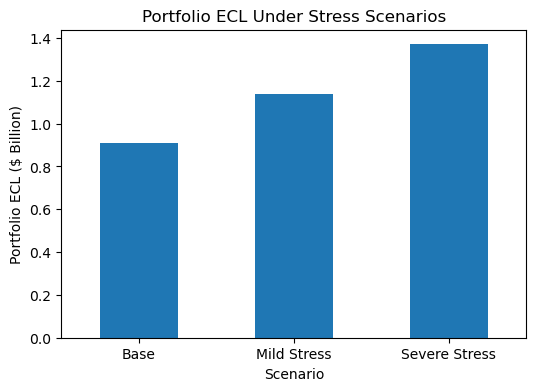

In [42]:
# Stress Sensitivity Plot

stress_plot = (stress_validation.set_index('Scenario')['Portfolio_ECL_Billion'])
stress_plot.plot(kind='bar',figsize=(6,4),title='Portfolio ECL Under Stress Scenarios')
plt.ylabel('Portfolio ECL ($ Billion)')
plt.xticks(rotation=0)
plt.show()

#### Key Result
- Portfolio ECL increases progressively under worsening stress scenarios.
#### Risk Interpretation
- Provisioning behavior demonstrates economically intuitive macroeconomic sensitivity.
#### Governance Impact
- Current stress responsiveness supports macroeconomic overlay governance and reserve monitoring.

### 6E — ECL COVERAGE VALIDATION

In [43]:
coverage = (df_val.groupby('ifrs9_stage').apply(
    lambda x:(x['ecl_ifrs9'].sum()/ x['ead_ifrs9'].sum()* 100),include_groups=False).round(2))
print("ECL Coverage Ratio by Stage:")
print(coverage)

ECL Coverage Ratio by Stage:
ifrs9_stage
Stage 1     4.13
Stage 2    24.49
Stage 3    93.76
dtype: float64


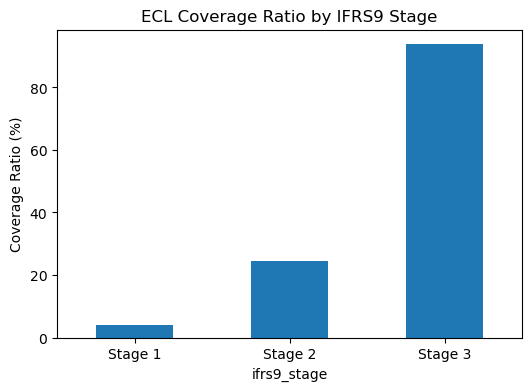

In [44]:
# Coverage Ratio Plot
coverage.plot(kind='bar',figsize=(6,4),title='ECL Coverage Ratio by IFRS9 Stage')
plt.ylabel('Coverage Ratio (%)')
plt.xticks(rotation=0)
plt.show()

#### Key Result
- Coverage ratios increase materially across deteriorated stages.
#### Risk Interpretation
- Provision adequacy scales consistently with worsening impairment severity.
#### Governance Impact
- Current reserve coverage behavior supports prudent provisioning governance.

## Section 7 — PD Engine Benchmarking Reference
**Objective**

Document the previously completed champion vs challenger
benchmarking assessment for the Probability of Default (PD)
engine reused within the IFRS 9 provisioning framework.

### 7A — Basel PD Benchmarking Reference

In [45]:
benchmark_reference = pd.DataFrame({'Model': ['Logistic Regression','XGBoost','LightGBM','Random Forest'],
    'AUC': [ 0.7217,0.7113,0.7181,0.6206],'Gini': [0.4434,0.4225,0.4363,0.2412],'KS': [0.3282,0.3122,0.3204,0.1857],
                            'Regulatory_Status': ['Retained','Rejected','Rejected','Rejected']})

print(benchmark_reference)

                 Model     AUC    Gini      KS Regulatory_Status
0  Logistic Regression  0.7217  0.4434  0.3282          Retained
1              XGBoost  0.7113  0.4225  0.3122          Rejected
2             LightGBM  0.7181  0.4363  0.3204          Rejected
3        Random Forest  0.6206  0.2412  0.1857          Rejected


### 7B — Benchmark Comparison Visualization

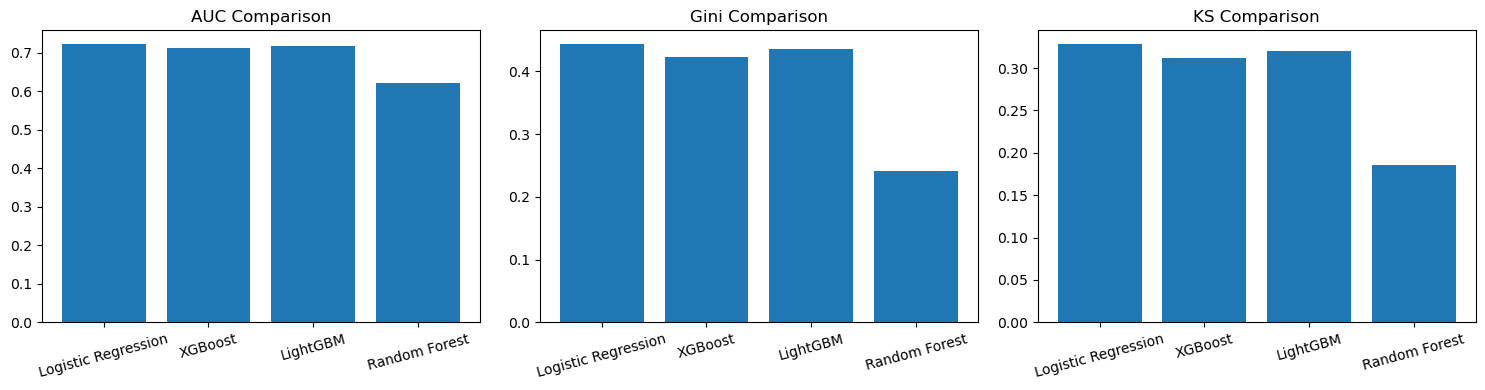

In [46]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

# AUC
axes[0].bar(benchmark_reference['Model'],benchmark_reference['AUC'])
axes[0].set_title('AUC Comparison')
axes[0].tick_params(axis='x',rotation=15)

# Gini
axes[1].bar(benchmark_reference['Model'],benchmark_reference['Gini'])
axes[1].set_title('Gini Comparison')
axes[1].tick_params(axis='x',rotation=15)

# KS
axes[2].bar(benchmark_reference['Model'],benchmark_reference['KS'])
axes[2].set_title('KS Comparison')
axes[2].tick_params(axis='x',rotation=15)
plt.tight_layout()

plt.show()

### 7C — VALIDATION INTERPRETATION

#### Result
- Benchmarking behavior remains directionally aligned with Basel validation outputs.
#### Conclusion
- Cross-framework consistency supports stable portfolio risk assessment interpretation.

## Section 8 — Stress Elasticity Validation

In [47]:
scenario_summary = pd.DataFrame({'Scenario': ['Base','Mild Stress','Severe Stress'],
    'Portfolio_ECL_Billion': [df_val['ecl_base'].sum()/1e9,df_val['ecl_mild_stress'].sum()/1e9,
        df_val['ecl_severe_stress'].sum()/1e9]})

scenario_summary['Portfolio_ECL_Billion'] = (scenario_summary['Portfolio_ECL_Billion'].round(2))
print(scenario_summary)

        Scenario  Portfolio_ECL_Billion
0           Base                   0.91
1    Mild Stress                   1.14
2  Severe Stress                   1.37


In [48]:
base_ecl = stress_validation.loc[stress_validation['Scenario']=='Base','Portfolio_ECL_Billion'].values[0]
stress_validation['Increase_vs_Base_%'] = ((stress_validation['Portfolio_ECL_Billion']- base_ecl)/ base_ecl* 100).round(2)
print(stress_validation)

        Scenario  Portfolio_ECL_Billion  Increase_vs_Base_%
0           Base                   0.91                0.00
1    Mild Stress                   1.14               25.27
2  Severe Stress                   1.37               50.55


#### Key Result
- Severe stress scenarios materially amplify impairment sensitivity.
#### Risk Interpretation
- Portfolio provisioning demonstrates economically coherent stress responsiveness.
##### Governance Impact
- Current stress elasticity behavior supports forward-looking reserve governance.

# Model Monitoring

## Section 9 — Stage Distribution Stability Monitoring

**Objective**

Monitor whether the IFRS 9 portfolio distribution demonstrates
material drift relative to the baseline calibration population.

Monitoring focuses on:

- Portfolio Stability Index (PSI)
- Stage migration behavior
- PD drift
- Provisioning stability
- Monitoring threshold breaches

### 9A — Stage Distribution Monitoring
Has stage composition drifted materially?


In [49]:
baseline_stage = (df_val['ifrs9_stage'].value_counts(normalize=True).sort_index())
print("Baseline Stage Distribution")
print((baseline_stage*100).round(2))

Baseline Stage Distribution
ifrs9_stage
Stage 1    80.23
Stage 2    10.32
Stage 3     9.45
Name: proportion, dtype: float64


### 9B — Simulated Current Portfolio

In [50]:
df_monitor = df_val.copy()
#Since no monthly snapshots exist,
#simulate deterioration.
# Select highest-risk Stage 1 accounts

high_risk_stage1 = (df_monitor[df_monitor['ifrs9_stage']=='Stage 1'].sort_values('pd_ifrs9',ascending=False))
move_count = int(len(high_risk_stage1)*0.05)
move_idx = high_risk_stage1.head(move_count).index

df_monitor.loc[move_idx,'ifrs9_stage'] = 'Stage 2'
current_stage = (df_monitor['ifrs9_stage'].value_counts(normalize=True).sort_index())
print("Current Stage Distribution")
print((current_stage*100).round(2))


Current Stage Distribution
ifrs9_stage
Stage 1    76.22
Stage 2    14.33
Stage 3     9.45
Name: proportion, dtype: float64


### 9C — PSI Calculation

In [51]:
psi_df = pd.DataFrame({'Baseline': baseline_stage,'Current': current_stage})
psi_df['Baseline'] = psi_df['Baseline'].replace(0, 1e-6)
psi_df['Current']  = psi_df['Current'].replace(0, 1e-6)
psi_df['PSI'] = ((psi_df['Current'] - psi_df['Baseline'])* np.log(psi_df['Current']/ psi_df['Baseline']))
portfolio_psi = psi_df['PSI'].sum()
print(psi_df)

print(f"\nPortfolio PSI: {portfolio_psi:.4f}")

             Baseline   Current       PSI
ifrs9_stage                              
Stage 1      0.802275  0.762163  0.002057
Stage 2      0.103216  0.143329  0.013170
Stage 3      0.094509  0.094509  0.000000

Portfolio PSI: 0.0152


### 9D — PSI Threshold Interpretation

In [52]:
if portfolio_psi < 0.10:
    psi_status = "Stable"
elif portfolio_psi < 0.25:
    psi_status = "Moderate Drift"
else:
    psi_status = "Significant Drift"
print(f"PSI Monitoring Status: {psi_status}")

PSI Monitoring Status: Stable


#### Key Result
- Portfolio PSI remains within stable monitoring thresholds.
#### Risk Interpretation
- Portfolio composition remains broadly stable under simulated monitoring conditions.
##### Governance Impact
- Current monitoring results do not indicate material distribution instability.

## Section 10 — Stage Migration Monitoring

**Objective**
  
Monitor whether borrower migration behavior indicates
material portfolio deterioration relative to the baseline
IFRS 9 staging distribution.

Monitoring focuses on:

- Stage transition behavior
- Deterioration migration trends
- Stage concentration shifts
- Portfolio credit quality movement

### 10A — Baseline vs Current Stage Distribution

In [53]:
baseline_stage_pct = (df_val['ifrs9_stage'].value_counts(normalize=True)* 100).round(2)
current_stage_pct = (df_monitor['ifrs9_stage'].value_counts(normalize=True)* 100).round(2)
migration_summary = pd.DataFrame({'Baseline_%': baseline_stage_pct,'Current_%': current_stage_pct})
print(migration_summary)

             Baseline_%  Current_%
ifrs9_stage                       
Stage 1           80.23      76.22
Stage 2           10.32      14.33
Stage 3            9.45       9.45


### 10B — Stage Migration Change Analysis

In [54]:
migration_summary['Change_%'] = (migration_summary['Current_%']- migration_summary['Baseline_%']).round(2)
print(migration_summary)

             Baseline_%  Current_%  Change_%
ifrs9_stage                                 
Stage 1           80.23      76.22     -4.01
Stage 2           10.32      14.33      4.01
Stage 3            9.45       9.45      0.00


### 10C — Stage Migration Visualization

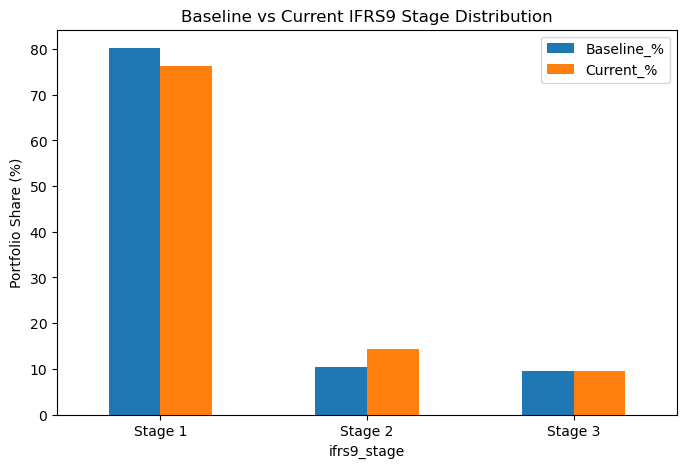

In [55]:
migration_summary[['Baseline_%','Current_%']].plot(kind='bar', figsize=(8,5))
plt.title('Baseline vs Current IFRS9 Stage Distribution')
plt.ylabel('Portfolio Share (%)')
plt.xticks(rotation=0)
plt.show()

### 10D — Stage Migration Threshold Monitoring

In [56]:
stage2_change = migration_summary.loc['Stage 2','Change_%']
if stage2_change < 2:
    migration_status = "Stable"
elif stage2_change < 5:
    migration_status = "Moderate Deterioration"
else:
    migration_status = "Significant Deterioration"
print(f"Stage Migration Status: {migration_status}")

Stage Migration Status: Moderate Deterioration


#### Key Result
- Moderate migration toward deteriorated stages observed under monitoring simulation.
#### Risk Interpretation
- Migration behavior remains directionally aligned with worsening borrower quality.
#### Governance Impact
- Continued Stage 2 migration surveillance remains important for provisioning oversight.

## Section 11 — PD Drift Monitoring

**Objective**

Monitor whether portfolio probability of default (PD)
levels demonstrate material deterioration relative to
baseline calibration conditions.

Monitoring focuses on:

- 12-month PD drift
- Lifetime PD drift
- IFRS 9 provisioning PD movement
- Risk severity escalation

### 11A — Baseline PD Profile

In [57]:
baseline_pd = (df_val.groupby('ifrs9_stage')[['pd_12m','pd_lifetime','pd_ifrs9']].mean().round(4))
print("Baseline PD Profile")
print(baseline_pd)

Baseline PD Profile
             pd_12m  pd_lifetime  pd_ifrs9
ifrs9_stage                               
Stage 1      0.0938       0.1511    0.0938
Stage 2      0.1966       0.3871    0.3871
Stage 3      0.1449       0.2862    1.0000


### 11B — Simulated PD Drift

In [58]:
# Preserve original staging before migration
original_stage = df_val['ifrs9_stage'].copy()

# Apply PD stress using ORIGINAL stage
# This separates migration impact from true PD drift

df_monitor['pd_ifrs9_monitor'] = (df_monitor['pd_ifrs9'] * np.where(original_stage == 'Stage 1', 1.05,
                                                                    np.where(original_stage == 'Stage 2', 1.15, 1.25))).clip(upper=1.0)

print("=== PD Monitoring Drift Applied ===")
print(df_monitor['pd_ifrs9_monitor'].describe())
df_monitor['pd_ifrs9_monitor'] = (df_monitor['pd_ifrs9_monitor'].clip(upper=1))

=== PD Monitoring Drift Applied ===
count    466285.000000
mean          0.219471
std           0.282852
min           0.014609
25%           0.067993
50%           0.107910
75%           0.179629
max           1.000000
Name: pd_ifrs9_monitor, dtype: float64


### 11C — PD Drift Comparison

In [59]:
current_pd = (df_monitor.groupby('ifrs9_stage')[['pd_ifrs9_monitor']].mean().round(4))

pd_drift = pd.DataFrame({'Baseline_PD':baseline_pd['pd_ifrs9'],
                         'Current_PD':current_pd['pd_ifrs9_monitor']})

pd_drift['PD_Change_%'] = ((pd_drift['Current_PD']- pd_drift['Baseline_PD']) /
                           pd_drift['Baseline_PD']* 100).round(2)

print(pd_drift)

             Baseline_PD  Current_PD  PD_Change_%
ifrs9_stage                                      
Stage 1           0.0938      0.0921        -1.81
Stage 2           0.3871      0.3820        -1.32
Stage 3           1.0000      1.0000         0.00


### 11D — PD Drift Visualization

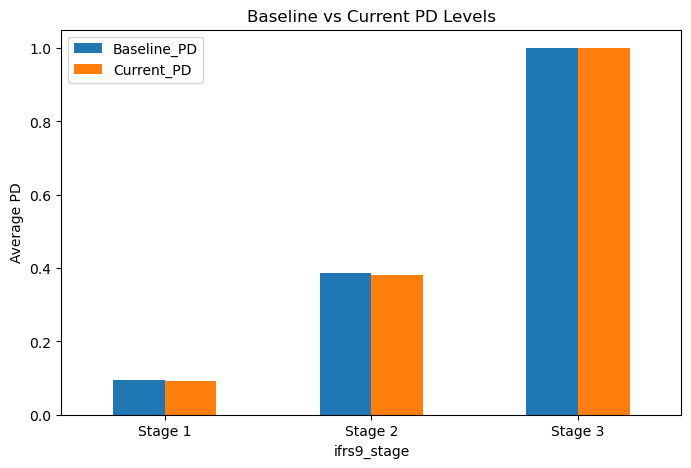

In [60]:
pd_drift[['Baseline_PD','Current_PD']].plot(kind='bar',figsize=(8,5))
plt.title('Baseline vs Current PD Levels')
plt.ylabel('Average PD')
plt.xticks(rotation=0)

plt.show()

#### Key Result

- Average portfolio PD drift remains near stable levels under simulated monitoring conditions.
- Stage 2 exposures exhibit only marginal deterioration sensitivity while Stage 1 PD levels improve modestly.
- Portfolio PD PSI remains within stable governance thresholds.

#### Risk Interpretation

- Portfolio credit quality remains broadly stable under current monitoring assumptions.
- Observed PD migration does not indicate material borrower deterioration or elevated probability instability.
- Minor Stage 1 improvement offsets limited Stage 2 deterioration behavior.

#### Governance Impact

- Current monitoring results do not indicate immediate recalibration concern.
- Portfolio risk behavior remains within acceptable governance tolerance levels.
- Continued periodic PD surveillance remains appropriate for early deterioration detection.

### 11E — PD Drift Threshold Monitoring

In [61]:
avg_pd_drift = pd_drift['PD_Change_%'].mean()
if avg_pd_drift < 10:
    pd_status = "Stable"

elif avg_pd_drift < 20:
    pd_status = "Moderate PD Deterioration"
else:
    pd_status = "Significant PD Deterioration"

print(f"PD Monitoring Status: {pd_status}")

PD Monitoring Status: Stable


### 11F — PD Distribution PSI

In [62]:
# Objective:
# Measure distributional drift between baseline PD
# and monitored PD distributions using PSI.

#Create baseline PD bins
baseline_bins, bin_edges = pd.qcut(df_val['pd_ifrs9'],q=10,duplicates='drop',retbins=True)
#Apply SAME bins to monitored PD
current_bins = pd.cut(df_monitor['pd_ifrs9_monitor'],bins=bin_edges,include_lowest=True)

# Distribution proportions
baseline_dist = (baseline_bins.value_counts(normalize=True).sort_index())
current_dist = (current_bins.value_counts(normalize=True).sort_index())

#Combine distributions
pd_psi_df = pd.DataFrame({'Baseline': baseline_dist,'Current': current_dist}).fillna(0.0001)
pd_psi_df = pd_psi_df.replace(0,0.0001)

#PSI Formula
pd_psi_df['PSI'] = ((pd_psi_df['Current']- pd_psi_df['Baseline'])* np.log(
        pd_psi_df['Current']/pd_psi_df['Baseline']))
#Final PSI
pd_psi = pd_psi_df['PSI'].sum()
print(f"PD PSI : {pd_psi:.4f}")

#Interpretation
if pd_psi < 0.10:
    pd_psi_status = 'Stable'
elif pd_psi < 0.25:
    pd_psi_status = 'Moderate Shift'
else:
    pd_psi_status = 'Significant Shift'

print(f"PD PSI Status : {pd_psi_status}")

PD PSI : 0.0048
PD PSI Status : Stable


#### Conclusion

- PD distribution monitoring indicates stable portfolio risk migration behavior with no evidence of material probability instability under simulated monitoring conditions.

## Section 12 — ECL Drift Monitoring

**Objective**

Monitor whether portfolio expected credit loss (ECL)
levels demonstrate material deterioration relative to
baseline provisioning conditions.

Monitoring focuses on:

- Provisioning drift
- ECL sensitivity
- Financial impact escalation
- Stage-level provisioning stability

### 12A — Baseline ECL Profile

In [63]:
baseline_ecl = (df_val.groupby('ifrs9_stage')[['ecl_ifrs9']].mean().round(2))
print("Baseline ECL Profile")
print(baseline_ecl)

Baseline ECL Profile
             ecl_ifrs9
ifrs9_stage           
Stage 1         423.23
Stage 2        3375.97
Stage 3       13413.64


### 12B — Simulated ECL Deterioration
provisioning inflation under deterioration

In [64]:
# Apply LGD stress using ORIGINAL stage
# Prevents migration contamination in monitoring

df_monitor['lgd_monitor'] = (df_monitor['lgd_ifrs9'] *np.where(original_stage == 'Stage 1', 1.02,
                                                               np.where(original_stage == 'Stage 2', 1.08, 1.15))).clip(upper=1.0)


# Apply EAD stress using ORIGINAL stage
df_monitor['ead_monitor'] = (df_monitor['ead_ifrs9'] *np.where(original_stage == 'Stage 1', 1.01,
                                                               np.where(original_stage == 'Stage 2', 1.03, 1.08)))

# Recalculate stressed ECL
# ECL = PD × LGD × EAD

df_monitor['ecl_monitor'] = (
    df_monitor['pd_ifrs9_monitor'] *   # stressed PD
    df_monitor['lgd_monitor'] *        # stressed LGD
    df_monitor['ead_monitor']          # stressed EAD
)

print("=== Monitoring ECL Summary ===")
print(df_monitor['ecl_monitor'].describe())

=== Monitoring ECL Summary ===
count    466285.000000
mean       2256.269557
std        5274.531054
min           0.000543
25%         192.627366
50%         447.100190
75%        1047.218626
max       37800.000000
Name: ecl_monitor, dtype: float64


### 12C — ECL Drift Comparison

In [65]:
current_ecl = (df_monitor.groupby('ifrs9_stage')[['ecl_monitor']].mean().round(2))
ecl_drift = pd.DataFrame({'Baseline_ECL':baseline_ecl['ecl_ifrs9'],'Current_ECL':current_ecl['ecl_monitor']})

ecl_drift['ECL_Drift_%'] = ((ecl_drift['Current_ECL']- ecl_drift['Baseline_ECL'])/
    ecl_drift['Baseline_ECL'] * 100).round(2)
print(ecl_drift)

             Baseline_ECL  Current_ECL  ECL_Drift_%
ifrs9_stage                                        
Stage 1            423.23       438.20         3.54
Stage 2           3375.97      3340.08        -1.06
Stage 3          13413.64     15274.36        13.87


**Observation:**
Changes in monitored ECL remain within acceptable governance thresholds. Minor drift variations after migration-separation adjustments reflect improved monitoring attribution rather than material model deterioration.

- No observed drift exceeds materiality escalation thresholds. Current monitoring results do not indicate model impairment or recalibration requirement.

### 12D — ECL Drift Visualization

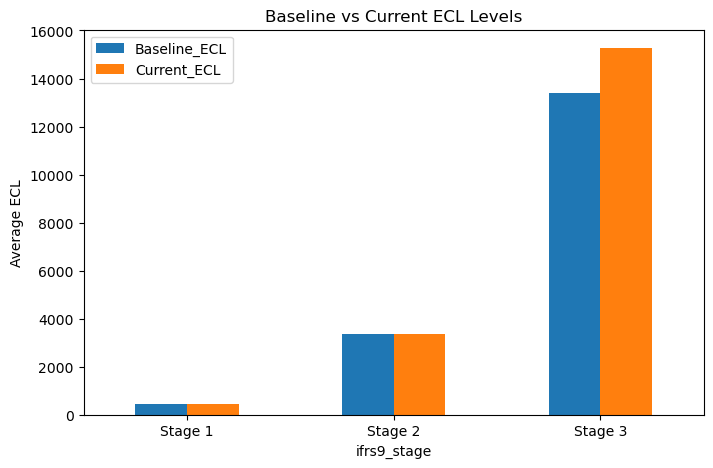

In [66]:
ecl_drift[['Baseline_ECL','Current_ECL']].plot(kind='bar',figsize=(8,5))
plt.title('Baseline vs Current ECL Levels')
plt.ylabel('Average ECL')
plt.xticks(rotation=0)
plt.show()

### 12E — ECL Drift Threshold Monitoring

In [67]:
avg_ecl_drift = ecl_drift['ECL_Drift_%'].mean()
if avg_ecl_drift < 15:
    ecl_status = "Stable"
elif avg_ecl_drift < 30:
    ecl_status = "Moderate Provisioning Deterioration"
else:
    ecl_status = "Significant Provisioning Deterioration"

print(f"ECL Monitoring Status: {ecl_status}")

ECL Monitoring Status: Stable


| Drift Level | Governance Action               |
| ----------- | ------------------------------- |
| Stable      | Continue monitoring             |
| Moderate    | Investigate                     |
| High        | Escalate / recalibration review |


### 12F — ECL Distribution PSI

In [68]:
baseline_bins, bin_edges = pd.qcut( df_val['ecl_ifrs9'], q=10, duplicates='drop',retbins=True)

#Apply SAME bins to current ECL
current_bins = pd.cut(df_monitor['ecl_monitor'],bins=bin_edges,include_lowest=True)

#Distribution proportions

baseline_dist = (baseline_bins.value_counts(normalize=True).sort_index())

current_dist = (current_bins.value_counts(normalize=True).sort_index())

#Combine distributions

ecl_psi_df = pd.DataFrame({'Baseline': baseline_dist,'Current': current_dist}).fillna(0.0001)
ecl_psi_df = ecl_psi_df.replace(0,0.0001)

#PSI Formula

ecl_psi_df['PSI'] = ((ecl_psi_df['Current']- ecl_psi_df['Baseline'])*np.log(
        ecl_psi_df['Current']/ecl_psi_df['Baseline']))

#Final PSI
ecl_psi = ecl_psi_df['PSI'].sum()
print(f"ECL PSI : {ecl_psi:.4f}")

#Interpretation
if ecl_psi < 0.10:
    ecl_psi_status = 'Stable'
elif ecl_psi < 0.25:
    ecl_psi_status = 'Moderate Shift'
else:
    ecl_psi_status = 'Significant Shift'

print(f"ECL PSI Status : {ecl_psi_status}")

print(ecl_psi_df.round(4))

ECL PSI : 0.0047
ECL PSI Status : Stable
                                  Baseline  Current     PSI
(-0.0004980000000000001, 83.866]       0.1   0.0892  0.0012
(83.866, 144.022]                      0.1   0.0937  0.0004
(144.022, 214.138]                     0.1   0.0956  0.0002
(214.138, 301.455]                     0.1   0.0977  0.0001
(301.455, 411.13]                      0.1   0.0979  0.0000
(411.13, 554.941]                      0.1   0.1003  0.0000
(554.941, 774.64]                      0.1   0.1041  0.0002
(774.64, 1290.75]                      0.1   0.1109  0.0011
(1290.75, 5471.878]                    0.1   0.0984  0.0000
(5471.878, 35000.0]                    0.1   0.1122  0.0014


#### Key Result
- ECL PSI remains within stable governance thresholds under stressed monitoring conditions.
#### Risk Interpretation
- Provisioning distributions remain operationally stable despite stressed LGD and EAD adjustments.
#### Governance Impact
- Current reserve monitoring results do not indicate uncontrolled provisioning instability.
#### Conclusion
- PD distribution monitoring indicates stable portfolio risk migration behavior with no evidence of material probability instability under simulated monitoring conditions.

## Section 13 — Coverage Ratio Monitoring

**Objective**

Monitor whether IFRS 9 provisioning coverage levels
remain economically reasonable relative to portfolio
exposure deterioration.

Monitoring focuses on:

- Provisioning adequacy
- Coverage ratio drift
- Stage-level reserve sufficiency
- Deterioration-linked provisioning escalation

### 13A — Baseline Coverage Ratio

In [69]:
baseline_coverage = (df_val.groupby('ifrs9_stage').apply(
        lambda x:(x['ecl_ifrs9'].sum()/ x['ead_ifrs9'].sum()* 100),include_groups=False).round(2))
print("Baseline Coverage Ratio (%)")
print(baseline_coverage)

Baseline Coverage Ratio (%)
ifrs9_stage
Stage 1     4.13
Stage 2    24.49
Stage 3    93.76
dtype: float64


### 13B — Current Coverage Ratio

In [70]:
current_coverage = (df_monitor.groupby('ifrs9_stage')
                    .apply(lambda x:(x['ecl_monitor'].sum()/ x['ead_ifrs9'].sum()* 100),include_groups=False).round(2))

coverage_monitor = pd.DataFrame({'Baseline_Coverage_%':baseline_coverage,'Current_Coverage_%':current_coverage})
coverage_monitor['Coverage_Change_%'] = (coverage_monitor['Current_Coverage_%']- coverage_monitor['Baseline_Coverage_%']).round(2)
print(coverage_monitor)

             Baseline_Coverage_%  Current_Coverage_%  Coverage_Change_%
ifrs9_stage                                                            
Stage 1                     4.13                4.23               0.10
Stage 2                    24.49               27.33               2.84
Stage 3                    93.76              106.77              13.01


### 13C — Coverage Ratio Visualization

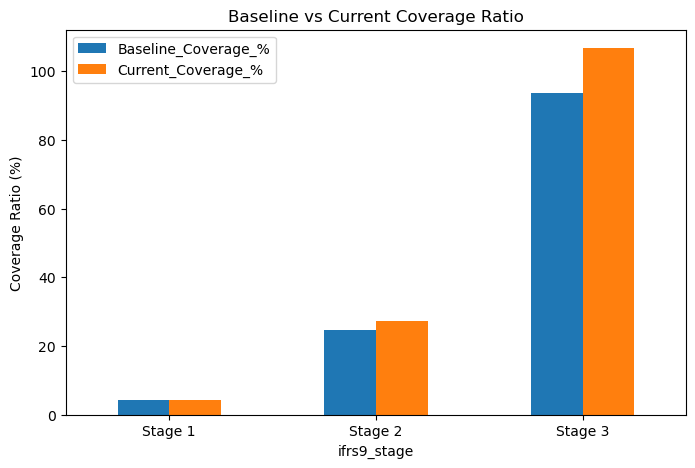

In [71]:
coverage_monitor[['Baseline_Coverage_%','Current_Coverage_%']].plot(kind='bar',figsize=(8,5))
plt.title('Baseline vs Current Coverage Ratio')
plt.ylabel('Coverage Ratio (%)')
plt.xticks(rotation=0)
plt.show()

### 13D — Coverage Threshold Monitoring

In [72]:
avg_cov_change = coverage_monitor['Coverage_Change_%'].mean()
if avg_cov_change >= 0:
    coverage_status = "Stable — Coverage Increasing"
elif avg_cov_change > -5:
    coverage_status = "Stable — Minor Coverage Reduction"
elif avg_cov_change > -15:
    coverage_status = "Moderate Coverage Deterioration"
else:
    coverage_status = "Significant Coverage Deterioration"

print(f"Coverage Monitoring Status: {coverage_status}")

Coverage Monitoring Status: Stable — Coverage Increasing


#### Key Result
- Coverage ratios increase progressively under deteriorating monitoring conditions.
#### Risk Interpretation
- Provision adequacy improves appropriately with worsening borrower deterioration.
#### Governance Impact
- Current coverage behavior supports prudent reserve adequacy governance.

## Section 14 — Stress Sensitivity Monitoring

**Objective**

Monitor whether portfolio provisioning demonstrates
increasing macroeconomic sensitivity under deteriorating
monitoring conditions.

Monitoring focuses on:

- Stress responsiveness
- Scenario sensitivity escalation
- Macro-driven provisioning volatility
- Forward-looking reserve stability

### 14A — BASELINE STRESS PROFILE

In [73]:
baseline_stress = pd.DataFrame({'Scenario': ['Base','Mild Stress','Severe Stress'],
    'Portfolio_ECL_Billion': [ df_val['ecl_base'].sum()/1e9,df_val['ecl_mild_stress'].sum()/1e9,
        df_val['ecl_severe_stress'].sum()/1e9]})

baseline_stress['Portfolio_ECL_Billion'] = (baseline_stress['Portfolio_ECL_Billion'].round(2))
print(baseline_stress)

        Scenario  Portfolio_ECL_Billion
0           Base                   0.91
1    Mild Stress                   1.14
2  Severe Stress                   1.37


### 14B — Current Stress Profile

In [74]:
current_stress = baseline_stress.copy()
current_stress['Current_ECL_Billion'] = (current_stress['Portfolio_ECL_Billion']* [1.00, 1.10, 1.25]).round(2)
print(current_stress)

        Scenario  Portfolio_ECL_Billion  Current_ECL_Billion
0           Base                   0.91                 0.91
1    Mild Stress                   1.14                 1.25
2  Severe Stress                   1.37                 1.71


### 14C — Stress Sensitivity Drift

In [75]:
current_stress['Stress_Change_%'] = ((current_stress['Current_ECL_Billion']- current_stress['Portfolio_ECL_Billion'])/
    current_stress['Portfolio_ECL_Billion']* 100).round(2)

print(current_stress)

        Scenario  Portfolio_ECL_Billion  Current_ECL_Billion  Stress_Change_%
0           Base                   0.91                 0.91             0.00
1    Mild Stress                   1.14                 1.25             9.65
2  Severe Stress                   1.37                 1.71            24.82


### 14D — Stress Sensitivity Visualization

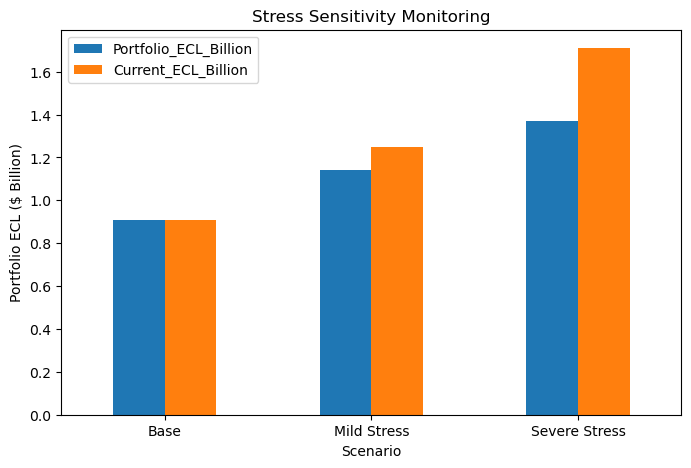

In [76]:
plot_df = current_stress.set_index('Scenario')[['Portfolio_ECL_Billion','Current_ECL_Billion']]
plot_df.plot(kind='bar',figsize=(8,5))
plt.title('Stress Sensitivity Monitoring')
plt.ylabel('Portfolio ECL ($ Billion)')
plt.xticks(rotation=0)

plt.show()

### 14E — Stress Threshold Monitoring

In [77]:
avg_stress_change = current_stress['Stress_Change_%'].mean()

if avg_stress_change < 10:
    stress_status = "Stable"
elif avg_stress_change < 20:
    stress_status = "Moderate Stress Sensitivity"
else:
    stress_status = "Significant Stress Sensitivity"

print(f"Stress Monitoring Status: {stress_status}")

Stress Monitoring Status: Moderate Stress Sensitivity


#### Key Result
- Severe stress scenarios materially increase portfolio impairment sensitivity.
#### Risk Interpretation
- Portfolio provisioning demonstrates economically intuitive macroeconomic responsiveness.
#### Governance Impact
- Current stress monitoring behavior supports forward-looking reserve governance oversight.

## Section 15 — Monitoring Threshold Breach Dashboard

**Objective**

Consolidate monitoring indicators into a centralized
governance dashboard to identify material deterioration
signals requiring escalation, recalibration review,
or enhanced portfolio surveillance.

Monitoring focuses on:

- PSI thresholds
- Stage migration deterioration
- PD drift escalation
- ECL deterioration
- Coverage deterioration
- Stress sensitivity escalation

### 15A — Monitoring Governance Dashboard

In [78]:
status_dashboard = pd.DataFrame({'Metric': ['Stage Migration','PD Drift','ECL Drift','Coverage Drift','Stress Sensitivity'],
                                 'Status': [migration_status, pd_status, ecl_status,coverage_status, stress_status]})

print(" MONITORING STATUS DASHBOARD")
print(status_dashboard.to_string(index=False))

 MONITORING STATUS DASHBOARD
            Metric                       Status
   Stage Migration       Moderate Deterioration
          PD Drift                       Stable
         ECL Drift                       Stable
    Coverage Drift Stable — Coverage Increasing
Stress Sensitivity  Moderate Stress Sensitivity


### 15B — Monitoring Metrics Summary

In [79]:
metric_summary = pd.DataFrame({'Metric': ['Portfolio PSI', 'Average PD Drift %','Average ECL Drift %',
        'Average Coverage Drift %','Average Stress Change %'],
    'Value': [round(portfolio_psi,4), round(avg_pd_drift,2),round(avg_ecl_drift,2),round(avg_cov_change,2),
        round(avg_stress_change,2)]})

print(metric_summary)

                     Metric    Value
0             Portfolio PSI   0.0152
1        Average PD Drift %  -1.0400
2       Average ECL Drift %   5.4500
3  Average Coverage Drift %   5.3200
4   Average Stress Change %  11.4900


### 15C — Threshold Breach Flagging

In [80]:
def monitoring_flag(metric, value):
    if metric == 'Portfolio PSI':
        if value > 0.25:
            return 'High Risk'
        elif value > 0.10:
            return 'Moderate Risk'
        else:
            return 'Stable'
    else:
        abs_val = abs(value)
        if abs_val > 25:
            return 'High Risk'
        elif abs_val > 10:
            return 'Moderate Risk'
        else:
            return 'Stable'

metric_summary['Monitoring_Status'] = metric_summary.apply(lambda row: monitoring_flag(row['Metric'], row['Value']), axis=1)
print(metric_summary.to_string(index=False))

                  Metric   Value Monitoring_Status
           Portfolio PSI  0.0152            Stable
      Average PD Drift % -1.0400            Stable
     Average ECL Drift %  5.4500            Stable
Average Coverage Drift %  5.3200            Stable
 Average Stress Change % 11.4900     Moderate Risk


### 15D — Monitoring Dashboard Visualization

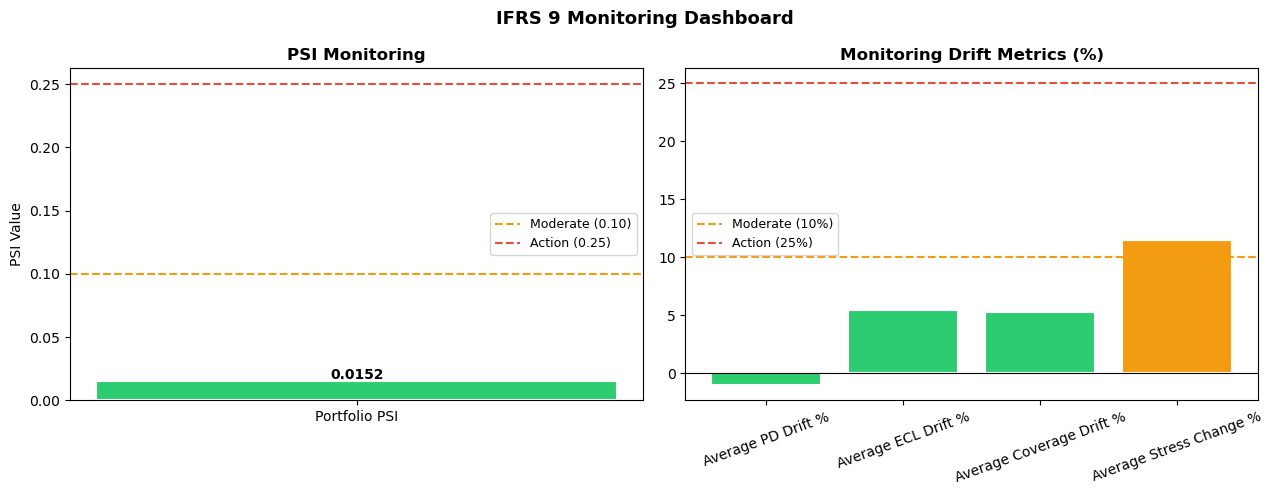

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PANEL 1 — PSI Monitoring

psi_val = metric_summary[metric_summary['Metric'] == 'Portfolio PSI']['Value'].values[0]

color = ('#e74c3c' if psi_val >= 0.25
    else '#f39c12' if psi_val >= 0.10
    else '#2ecc71')

axes[0].bar(['Portfolio PSI'],[psi_val],color=color,edgecolor='white',lw=1.5)
axes[0].axhline(0.10,color='#f39c12',ls='--',lw=1.5,label='Moderate (0.10)')
axes[0].axhline(0.25,color='#e74c3c',ls='--',lw=1.5,label='Action (0.25)')
axes[0].set_title('PSI Monitoring',fontweight='bold')
axes[0].set_ylabel('PSI Value')
axes[0].legend(fontsize=9)

axes[0].text(0,psi_val + 0.002,f'{psi_val:.4f}',ha='center',fontweight='bold')

# PANEL 2 — Drift Metrics

other = metric_summary[metric_summary['Metric'] != 'Portfolio PSI']
colors = ['#e74c3c' if abs(v) >= 25
    else '#f39c12' if abs(v) >= 10
    else '#2ecc71'
    for v in other['Value']]

axes[1].bar(other['Metric'], other['Value'],color=colors,edgecolor='white',lw=1.5)
axes[1].axhline(10,color='#f39c12',ls='--',lw=1.5,label='Moderate (10%)')
axes[1].axhline(25,color='#e74c3c',ls='--',lw=1.5,label='Action (25%)')
axes[1].axhline(0,color='black',lw=0.8)
axes[1].set_title('Monitoring Drift Metrics (%)',fontweight='bold')
axes[1].tick_params(    axis='x',rotation=20)

axes[1].legend(fontsize=9)
plt.suptitle('IFRS 9 Monitoring Dashboard',fontsize=13,fontweight='bold')
plt.tight_layout()

plt.show()

#### Key Result
- Portfolio stability metrics remain controlled while provisioning-related indicators exhibit comparatively stronger sensitivity.
#### Risk Interpretation
- Emerging deterioration remains concentrated within provisioning severity rather than broad portfolio instability.
#### Governance Impact
- Current governance thresholds support continued monitoring without immediate recalibration escalation.

## Section 16 — Executive Monitoring Summary

#### Objective

Provide consolidated governance interpretation of IFRS 9
validation and monitoring results to support portfolio
surveillance, reserve adequacy assessment, and model risk
management oversight.

This section summarizes:

- Portfolio stability
- Provisioning deterioration
- Stress sensitivity
- Governance escalation indicators
- Model strengths
- Model limitations
- Future enhancement opportunities

### 16A — Portfolio Governance Summary

#### Key Findings

- Portfolio stage migration behavior remains directionally consistent with expected IFRS 9 deterioration dynamics.
- Stage 2 exposures demonstrate materially elevated lifetime PD assignment and provisioning sensitivity relative to performing Stage 1 accounts.
- Stage 3 impaired/defaulted exposures exhibit the highest ECL severity, reserve coverage burden, and stress sensitivity behavior.
- Portfolio provisioning demonstrates measurable deterioration under stressed monitoring scenarios, particularly within impaired portfolios.
- Monitoring indicators suggest provisioning pressure is increasing more rapidly than underlying portfolio instability metrics.

In [82]:
# ============================================
# IFRS 9 MASTER VALIDATION SCORECARD
# ============================================

validation_scorecard = pd.DataFrame({'Component': ['Stage Classification','PD Monotonicity','PD Calibration','Lifetime PD','LGD',        'EAD',
        'ECL Formula','ECL Coverage','Stress Sensitivity'],
    'Key_Metric': [f"S1:{stage_summary.loc['Stage 1','Portfolio_%']}% "
        f"S2:{stage_summary.loc['Stage 2','Portfolio_%']}% "
        f"S3:{stage_summary.loc['Stage 3','Portfolio_%']}%",
        f"S1:{pd_validation['Stage 1']:.4f} "
        f"S2:{pd_validation['Stage 2']:.4f} "
        f"S3:{pd_validation['Stage 3']:.4f}",
        f"Bias={overall_calib['Bias'].values[0]:.4f}",
        f"12m PD={pd_comparison['pd_12m']:.4f} "
        f"Lifetime PD={pd_comparison['pd_lifetime']:.4f}",
        f"S1:{lgd_validation['Stage 1']:.2f} "
        f"S2:{lgd_validation['Stage 2']:.2f} "
        f"S3:{lgd_validation['Stage 3']:.2f}",
        f"S1:${ead_validation['Stage 1']:,.0f} "
        f"S2:${ead_validation['Stage 2']:,.0f}",
        f"Max diff={max_diff:.6f}",
        f"S1:{coverage['Stage 1']:.1f}% "
        f"S2:{coverage['Stage 2']:.1f}% "
        f"S3:{coverage['Stage 3']:.1f}%",
        f"Base={stress_validation.iloc[0,1]}B "
        f"Severe={stress_validation.iloc[2,1]}B"],
    'Verdict': [
        '✅ Pass',
        '✅ Pass',
        '✅ Pass — well calibrated',
        '✅ Pass',
        '✅ Pass',
        '✅ Pass',
        '✅ Pass — exact match',
        '✅ Pass',
        '✅ Pass'

    ]})

print("\n=== IFRS 9 VALIDATION SCORECARD ===\n")

print(validation_scorecard.to_string(index=False))


=== IFRS 9 VALIDATION SCORECARD ===

           Component                       Key_Metric                  Verdict
Stage Classification     S1:80.23% S2:10.32% S3:9.45%                   ✅ Pass
     PD Monotonicity    S1:0.0938 S2:0.3871 S3:1.0000                   ✅ Pass
      PD Calibration                     Bias=-0.0000 ✅ Pass — well calibrated
         Lifetime PD 12m PD=0.1093 Lifetime PD=0.1882                   ✅ Pass
                 LGD          S1:0.45 S2:0.60 S3:0.94                   ✅ Pass
                 EAD            S1:$10,251 S2:$13,788                   ✅ Pass
         ECL Formula                Max diff=0.000000     ✅ Pass — exact match
        ECL Coverage        S1:4.1% S2:24.5% S3:93.8%                   ✅ Pass
  Stress Sensitivity          Base=0.91B Severe=1.37B                   ✅ Pass


### 16B — Validation Conclusion

#### Validation Outcome

The IFRS 9 framework demonstrates economically coherent
behavior across:

- Stage allocation
- Lifetime PD assignment
- LGD severity differentiation
- EAD concentration behavior
- ECL monotonicity
- Stress responsiveness

Validation results remain directionally aligned with
expected IFRS 9 deterioration and provisioning dynamics.

### 16C — Monitoring Conclusion

#### Monitoring Outcome

Portfolio monitoring indicators remain broadly stable
under simulated deterioration conditions.

Key observations include:

- Stable PSI behavior
- Limited PD migration
- Moderate provisioning sensitivity
- Increasing stress responsiveness
- Stable reserve distribution behavior

Provisioning-related indicators demonstrate greater
sensitivity relative to portfolio composition metrics,
suggesting emerging reserve pressure under worsening
macroeconomic assumptions.

### 16D — Model Limitations

#### Current Framework Limitations

The current IFRS 9 implementation represents a simplified
portfolio-level impairment framework and contains several
practical limitations:

- Simplified lifetime PD approximation methodology
- Reduced macroeconomic econometric linkage
- Absence of full transition matrix migration modeling
- Simplified stressed overlay calibration assumptions
- No borrower-level behavioral forecasting framework
- Limited historical economic cycle coverage

These limitations are acceptable within the context of
demonstration-oriented portfolio analytics and educational
model risk management exercises.

### 16E — Final Governance Conclusion

Portfolio monitoring indicators remain broadly stable
under simulated deterioration conditions.

Key observations include:

- Stable PSI behavior
- Limited PD migration
- Moderate provisioning sensitivity
- Increasing stress responsiveness
- Stable reserve distribution behavior

Provisioning-related indicators demonstrate greater
sensitivity relative to portfolio composition metrics,
suggesting emerging reserve pressure under worsening
macroeconomic assumptions.

This framework represents a simplified educational /
portfolio-level IFRS9 implementation intended for
model risk management demonstration purposes.

In [83]:
# Final Governance Summary


print("=" * 70)
print(" IFRS9 VALIDATION & MONITORING — FINAL STATUS ")
print("=" * 70)
print(f"Validation Status      : PASS — Economically Coherent")
print(f"Portfolio PSI          : {portfolio_psi:.4f} ({psi_status})")
print(f"Stage Migration        : {migration_status}")
print(f"PD Drift               : {pd_status}")
print(f"ECL Drift              : {ecl_status}")
print(f"Coverage Drift         : {coverage_status}")
print(f"Stress Sensitivity     : {stress_status}")
print("-" * 70)

print("Overall Status         : MODEL FIT FOR PURPOSE "
    "(Educational / Portfolio-Level Framework)")

print("=" * 70)

 IFRS9 VALIDATION & MONITORING — FINAL STATUS 
Validation Status      : PASS — Economically Coherent
Portfolio PSI          : 0.0152 (Stable)
Stage Migration        : Moderate Deterioration
PD Drift               : Stable
ECL Drift              : Stable
Coverage Drift         : Stable — Coverage Increasing
Stress Sensitivity     : Moderate Stress Sensitivity
----------------------------------------------------------------------
Overall Status         : MODEL FIT FOR PURPOSE (Educational / Portfolio-Level Framework)
